## Implement image segmentation using basic global thresholding algorithm

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Basic Global Thresholding Function

In [4]:
def basic_global_thresholding(image, max_iterations=100, epsilon=0.5):
    T = np.mean(image)

    for _ in range(max_iterations):
        mask = image > T
        G1 = image[mask]
        G2 = image[~mask]

        if G1.size == 0 or G2.size == 0:
            break

        new_T = (np.mean(G1) + np.mean(G2)) / 2

        if abs(new_T - T) < epsilon:
            break

        T = new_T

    segmented = np.where(image > T, 255, 0).astype(np.uint8)
    return segmented, T


## applying basic Global Thresholding

Threshold value: 125.64968454931093


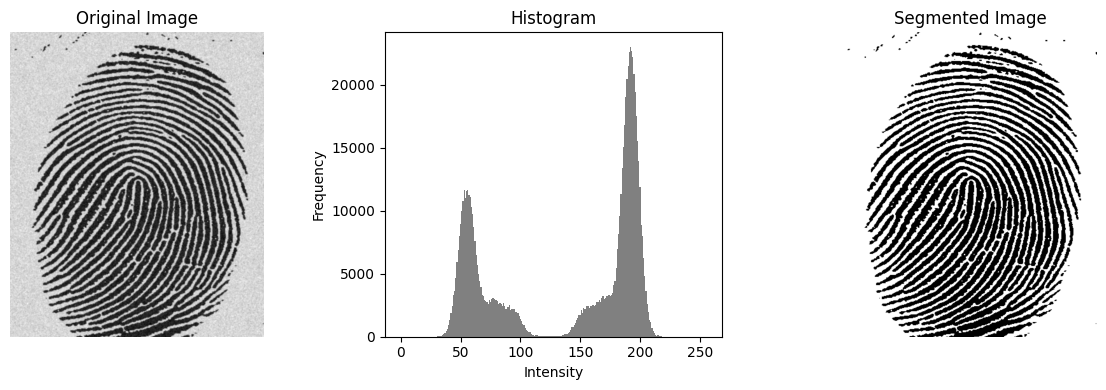

In [7]:
img = cv2.imread("fingerprint_seg.tif", cv2.IMREAD_GRAYSCALE)
hist = np.zeros(256)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        hist[img[i, j]] += 1

segmented, T = basic_global_thresholding(img)
print(f"Threshold value: {T}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')


plt.subplot(1, 3, 2)
plt.bar(range(256), hist, width=1.0, color = 'gray')
plt.title("Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.imshow(segmented, cmap='gray')
plt.title("Segmented Image")
plt.axis('off')

plt.tight_layout()
plt.show()
